In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
import joblib
import warnings
warnings.filterwarnings('ignore')




In [11]:
df = pd.read_csv('../data/synthetic_data/historical_dispatch.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFill % statistics:")
print(df['fill_percentage'].describe())

Dataset shape: (2000, 22)

Fill % statistics:
count    2000.000000
mean       85.131215
std         8.767371
min        70.010000
25%        77.630000
50%        84.960000
75%        92.892500
max       100.000000
Name: fill_percentage, dtype: float64


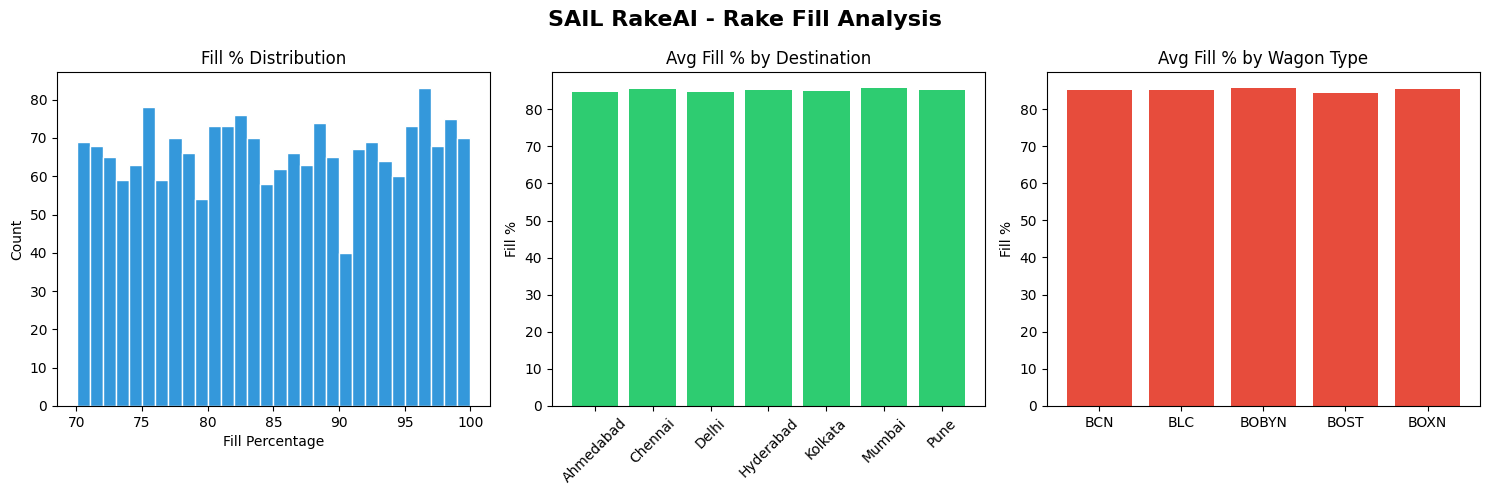

  saved


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('SAIL RakeAI - Rake Fill Analysis', 
             fontsize=16, fontweight='bold')

#  Fill % distribution
axes[0].hist(df['fill_percentage'], bins=30, 
             color='#3498db', edgecolor='white')
axes[0].set_title('Fill % Distribution')
axes[0].set_xlabel('Fill Percentage')
axes[0].set_ylabel('Count')

#  Fill % by destination
fill_by_dest = df.groupby('destination_city')['fill_percentage'].mean()
axes[1].bar(fill_by_dest.index, fill_by_dest.values, color='#2ecc71')
axes[1].set_title('Avg Fill % by Destination')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Fill %')

#  Fill % by wagon type
fill_by_wagon = df.groupby('wagon_type')['fill_percentage'].mean()
axes[2].bar(fill_by_wagon.index, fill_by_wagon.values, color='#e74c3c')
axes[2].set_title('Avg Fill % by Wagon Type')
axes[2].set_ylabel('Fill %')

plt.tight_layout()
plt.savefig('../ml/fill_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("  saved")

In [14]:

features = [
    'num_wagons',
    'quantity_tonnes',
    'distance_km',
    'pending_orders_count',
    'inventory_level',
    'dock_utilization',
    'is_month_end',
    'day_of_week',
    'month'
]

le = LabelEncoder()
df['wagon_type_encoded']    = le.fit_transform(df['wagon_type'])
df['destination_encoded']   = le.fit_transform(df['destination_city'])
features.append('wagon_type_encoded')
features.append('destination_encoded')

X = df[features]
y = df['fill_percentage']

print(f" Features: {len(features)}")
print(f" X shape: {X.shape}")
print(f" y shape: {y.shape}")
print(f"\nTarget variable range:")
print(f"   Min: {y.min():.1f}%")
print(f"   Max: {y.max():.1f}%")
print(f"   Mean: {y.mean():.1f}%")

 Features: 11
 X shape: (2000, 11)
 y shape: (2000,)

Target variable range:
   Min: 70.0%
   Max: 100.0%
   Mean: 85.1%


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f" Training set: {X_train.shape[0]} samples")
print(f" Testing set:  {X_test.shape[0]} samples")
print(f"\nFill % in training: {y_train.mean():.1f}%")
print(f"Fill % in testing:  {y_test.mean():.1f}%")

 Training set: 1600 samples
 Testing set:  400 samples

Fill % in training: 85.0%
Fill % in testing:  85.8%


In [16]:
xgb_regressor = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

print(" Training XGBoost Regressor...")
xgb_regressor.fit(X_train, y_train)
print(" Model trained successfully!")

y_pred = xgb_regressor.predict(X_test)

print(f"\nSample predictions vs actual:")
for i in range(5):
    print(f"   Predicted: {y_pred[i]:.1f}%  |  Actual: {y_test.iloc[i]:.1f}%")

 Training XGBoost Regressor...
 Model trained successfully!

Sample predictions vs actual:
   Predicted: 81.6%  |  Actual: 81.3%
   Predicted: 82.8%  |  Actual: 83.8%
   Predicted: 87.0%  |  Actual: 87.1%
   Predicted: 81.6%  |  Actual: 81.6%
   Predicted: 93.0%  |  Actual: 95.1%


In [7]:
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)


print("  SAIL RakeAI - Rake Fill Prediction Results")

print(f"\n RMSE  : {rmse:.4f}%")
print(f" MAE   : {mae:.4f}%")
print(f" R²    : {r2:.4f}")
print(f"\nInterpretation:")
print(f"   Model is off by {mae:.2f}% on average")
print(f"   R² of {r2:.2f} means model explains "
      f"{r2*100:.1f}% of variance in fill %")

  SAIL RakeAI - Rake Fill Prediction Results

 RMSE  : 1.6971%
 MAE   : 1.3130%
 R²    : 0.9605

Interpretation:
   Model is off by 1.31% on average
   R² of 0.96 means model explains 96.1% of variance in fill %


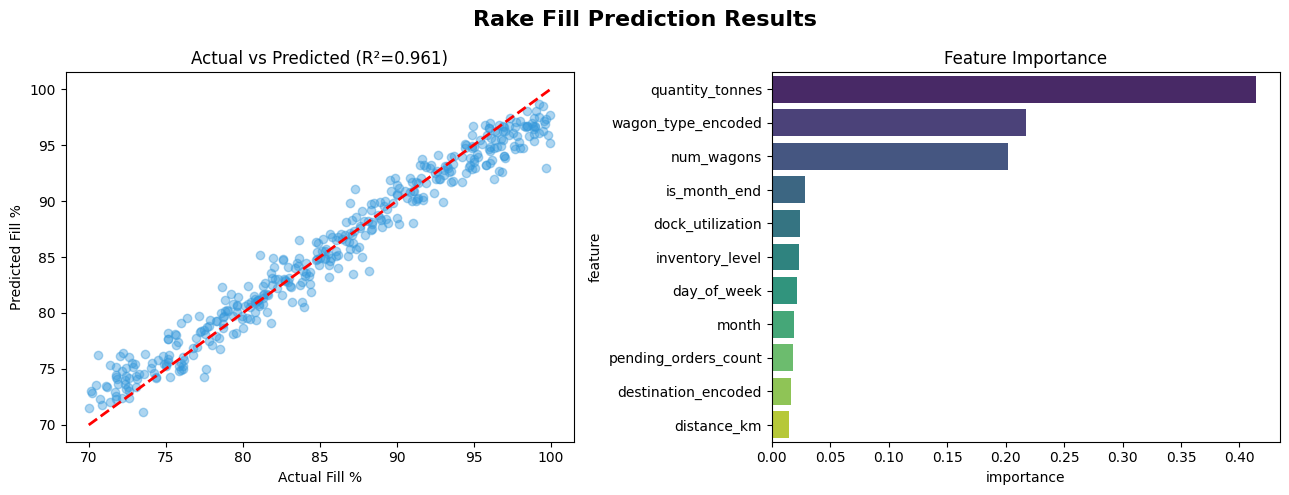

 Plot saved


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Rake Fill Prediction Results', 
             fontsize=16, fontweight='bold')

#  Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, color='#3498db')
axes[0].plot([70, 100], [70, 100], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Fill %')
axes[0].set_ylabel('Predicted Fill %')
axes[0].set_title(f'Actual vs Predicted (R²={r2:.3f})')


feat_imp = pd.DataFrame({
    'feature':    features,
    'importance': xgb_regressor.feature_importances_
}).sort_values('importance', ascending=False)

sns.barplot(data=feat_imp, x='importance', y='feature',
            palette='viridis', ax=axes[1])
axes[1].set_title('Feature Importance')

plt.tight_layout()
plt.savefig('../ml/fill_prediction_results.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved")

In [9]:
import os

save_dir = '../ml/saved_models'
os.makedirs(save_dir, exist_ok=True)

joblib.dump(xgb_regressor, f'{save_dir}/fill_prediction_model.pkl')
joblib.dump(features,      f'{save_dir}/fill_features.pkl')

print(" Model saved successfully!")
print(f"\n Model Summary:")
print(f"   Algorithm : XGBoost Regressor")
print(f"   Features  : {len(features)}")
print(f"   R²        : 0.9605")
print(f"   MAE       : 1.31%")
print(f"   RMSE      : 1.70%")
print(f"   Meaning   : Predictions within 1.31% of actual fill")

 Model saved successfully!

 Model Summary:
   Algorithm : XGBoost Regressor
   Features  : 11
   R²        : 0.9605
   MAE       : 1.31%
   RMSE      : 1.70%
   Meaning   : Predictions within 1.31% of actual fill
